# Analytics Metrics
Visualising returns, rolling volatility, drawdowns, and anomaly flags per ticker.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

metrics = pd.read_csv("../data/processed/analytics_metrics.csv", parse_dates=["date"])
prices  = pd.read_csv("../data/processed/market_prices.csv",    parse_dates=["date"])

print("Loaded:", metrics.shape)
metrics.head()

Loaded: (15060, 13)


,date,ticker,daily_return,cumulative_return,rolling_vol_30,rolling_vol_60,rolling_vol_90,moving_avg_50,moving_avg_200,drawdown,max_drawdown_to_date,volatility_z_score,anomaly_flag
0,2021-04-27,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0
1,2021-04-28,AAPL,-0.006027,-0.006027,NaN,NaN,NaN,NaN,NaN,-0.006027,-0.006027,NaN,0
2,2021-04-29,AAPL,-0.000748,-0.006771,NaN,NaN,NaN,NaN,NaN,-0.006771,-0.006771,NaN,0
3,2021-04-30,AAPL,-0.015133,-0.021802,NaN,NaN,NaN,NaN,NaN,-0.021802,-0.021802,NaN,0
4,2021-05-03,AAPL,0.008216,-0.013766,NaN,NaN,NaN,NaN,NaN,-0.013766,-0.021802,NaN,0


## 1. Cumulative Return per Ticker

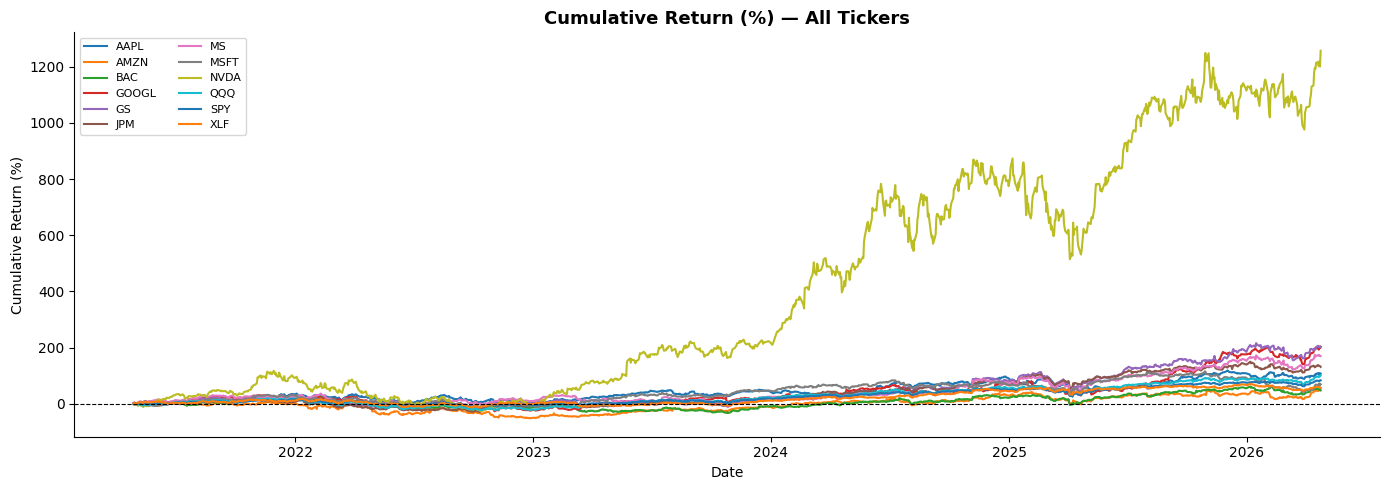

In [2]:
fig, ax = plt.subplots()

for ticker, group in metrics.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["cumulative_return"] * 100, label=ticker, linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Cumulative Return (%) — All Tickers", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 2. Rolling 30-Day Volatility

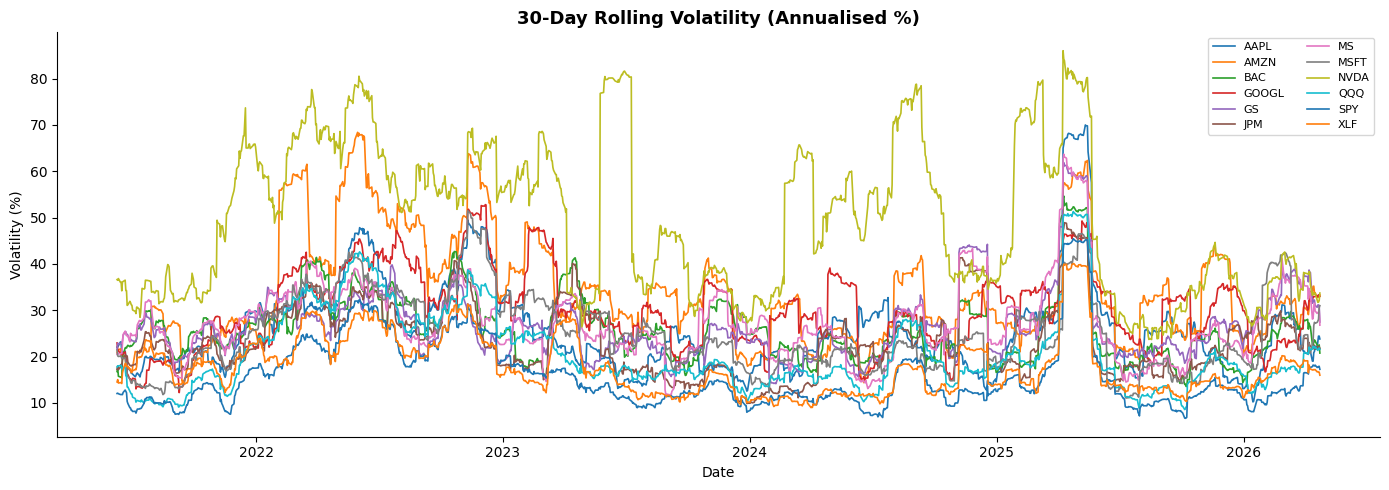

In [3]:
fig, ax = plt.subplots()

for ticker, group in metrics.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["rolling_vol_30"] * 100, label=ticker, linewidth=1.2)

ax.set_title("30-Day Rolling Volatility (Annualised %)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (%)")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 3. Drawdown per Ticker

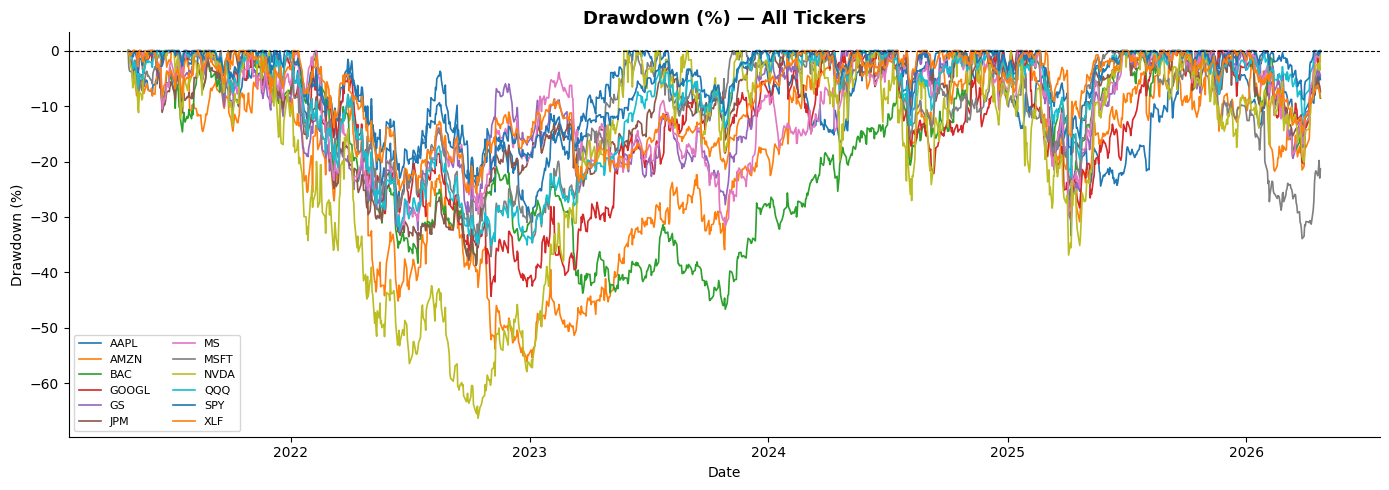

In [4]:
fig, ax = plt.subplots()

for ticker, group in metrics.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(group["date"], group["drawdown"] * 100, label=ticker, linewidth=1.2)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Drawdown (%) — All Tickers", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 4. Max Drawdown Summary (Bar Chart)

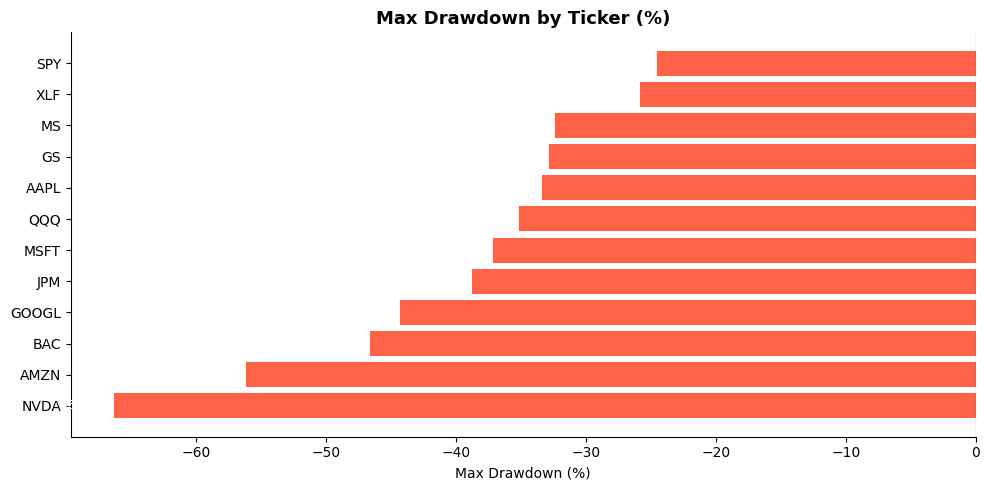

In [5]:
max_dd = (
    metrics.groupby("ticker")["drawdown"]
    .min()
    .sort_values()
    .reset_index()
)
max_dd["drawdown_pct"] = max_dd["drawdown"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(max_dd["ticker"], max_dd["drawdown_pct"], color="tomato", edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Max Drawdown by Ticker (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Max Drawdown (%)")
for bar, val in zip(bars, max_dd["drawdown_pct"]):
    ax.text(val - 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", ha="right", fontsize=9, color="white")
plt.tight_layout()
plt.show()

## 5. Moving Averages — Pick a Ticker

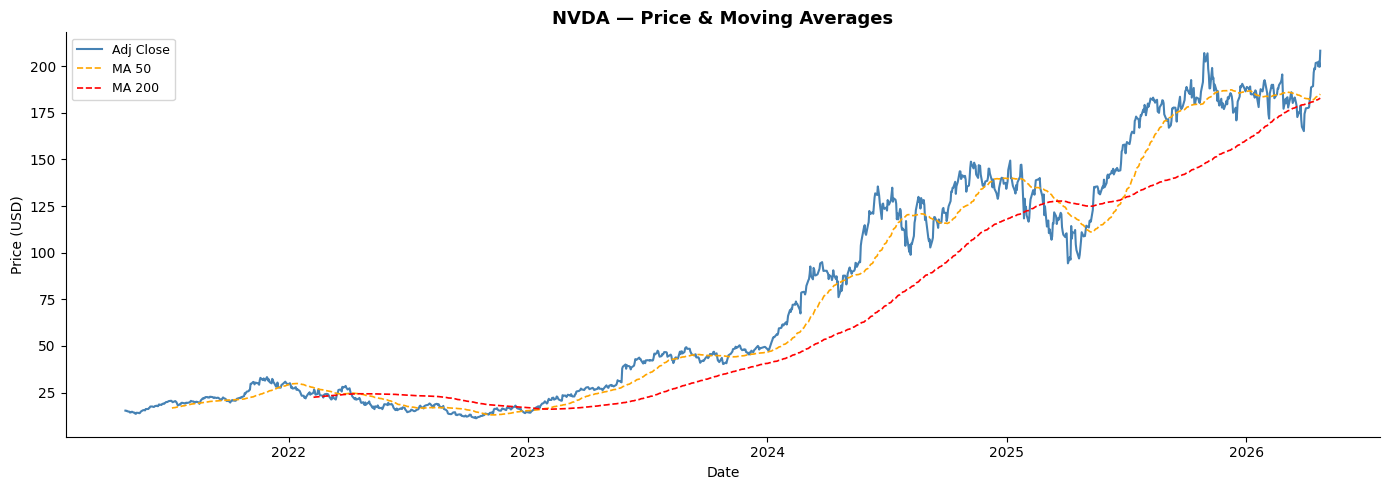

In [6]:
TICKER = "NVDA"  # change this to any ticker

p = prices[prices["ticker"] == TICKER].sort_values("date")
m = metrics[metrics["ticker"] == TICKER].sort_values("date")

fig, ax = plt.subplots()
ax.plot(p["date"], p["adj_close"],       label="Adj Close",  linewidth=1.5, color="steelblue")
ax.plot(m["date"], m["moving_avg_50"],   label="MA 50",      linewidth=1.2, color="orange",    linestyle="--")
ax.plot(m["date"], m["moving_avg_200"],  label="MA 200",     linewidth=1.2, color="red",       linestyle="--")

ax.set_title(f"{TICKER} — Price & Moving Averages", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## 6. Anomaly Flag Events

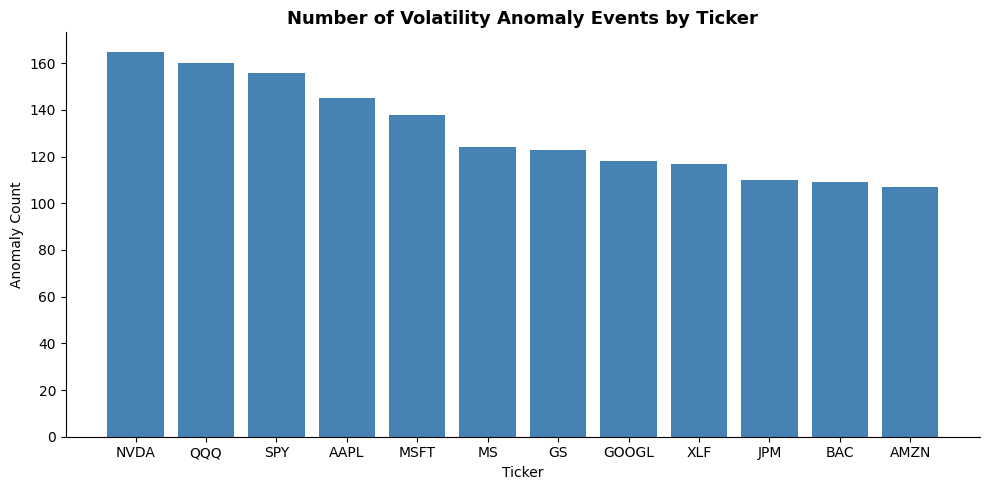

ticker  anomaly_count
  NVDA            165
   QQQ            160
   SPY            156
  AAPL            145
  MSFT            138
    MS            124
    GS            123
 GOOGL            118
   XLF            117
   JPM            110
   BAC            109
  AMZN            107


In [7]:
anomaly_counts = (
    metrics[metrics["anomaly_flag"] == 1]
    .groupby("ticker")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="anomaly_count")
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(anomaly_counts["ticker"], anomaly_counts["anomaly_count"], color="steelblue", edgecolor="none")
ax.set_title("Number of Volatility Anomaly Events by Ticker", fontsize=13, fontweight="bold")
ax.set_xlabel("Ticker")
ax.set_ylabel("Anomaly Count")
plt.tight_layout()
plt.show()

print(anomaly_counts.to_string(index=False))